In [40]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


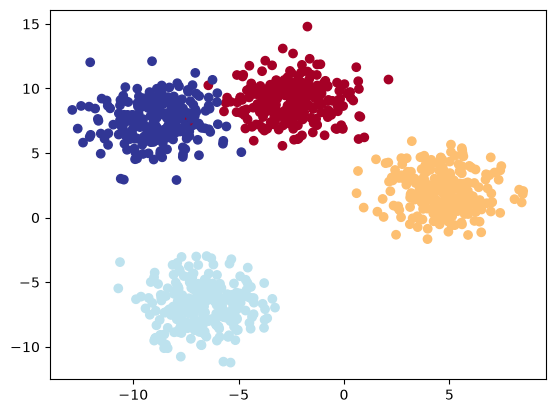

In [41]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(
  n_samples=1000,
  n_features=NUM_FEATURES,
  centers=NUM_CLASSES,
  cluster_std=1.5,
  random_state=RANDOM_SEED
)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

print(X_blob[:5], y_blob[:5])

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, train_size=0.2, random_state=RANDOM_SEED)

plt.Figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

Building Multiclass SubClass


In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [43]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [44]:
from torch import nn

class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):

    super().__init__()

    self.linear_layer_stack = nn.Sequential(
      nn.Linear(in_features=input_features, out_features=hidden_units),
      # nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=hidden_units),
      # nn.ReLU(),
      nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

In [45]:
model_4 = BlobModel(
  input_features=NUM_FEATURES,
  output_features=NUM_CLASSES,
  hidden_units=8
).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [46]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_4.parameters(), lr=0.1)

Train Before

In [47]:
model_4(X_blob_train.to(device))[:5]

tensor([[ 1.8550, -1.4871,  1.8516,  2.4065],
        [-0.6074, -0.8005, -0.7641, -0.0641],
        [ 1.9836, -1.2646,  2.0255,  2.3409],
        [ 0.5298, -1.4597,  0.3945,  1.3346],
        [ 1.7592, -1.2829,  1.7754,  2.1767]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [48]:
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES 

(torch.Size([4]), 4)

In [49]:
logits = model_4(X_blob_test.to(device))

y_pred_probs = torch.softmax(logits, dim=1)
print(logits[:5])
print(y_pred_probs[:5])

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [50]:
torch.sum(y_pred_probs[0])

tensor(1.0000, device='cuda:0', grad_fn=<SumBackward0>)

In [51]:
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.1872, 0.2918, 0.1495, 0.3715], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(3, device='cuda:0')


In [ ]:
torch.manual_seed(42)

epochs = 100

X_blob_train = X_blob_train.to(device)
X_blob_test = X_blob_test.to(device) 
y_blob_train = y_blob_train.to(device)
y_blob_test = y_blob_test.to(device) 

for epoch in range(epochs):
  model_4.train()

  y_logits = model_4(X_blob_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_blob_train)
  acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_4.eval()

  with torch.inference_mode():
    test_logits = model_4(X_blob_test).squeeze()
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)

  if epoch % 10 == 0:
    print(f"Epoch : {epoch} | Loss : {loss} | Acc : {acc}% | Test Loss : {test_loss} | Acc : {test_acc}%")

torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size([200])
torch.Size

In [53]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)

y_logits[:10]

tensor([[ 4.1207e+00,  1.1010e+01, -1.4860e+01, -1.0261e+01],
        [ 4.6721e+00, -1.2204e+01,  3.8184e+00,  1.0978e+01],
        [-5.2147e+00, -1.4245e+01,  2.0848e+01,  1.3433e+01],
        [ 1.7828e+00,  7.9469e+00, -8.6620e+00, -7.3163e+00],
        [ 7.5769e+00,  3.9134e+00, -1.4242e+01, -3.9636e+00],
        [ 5.1933e+00, -1.5196e+01,  5.5280e+00,  1.3688e+01],
        [-5.5627e+00, -1.0994e+01,  1.8652e+01,  1.0475e+01],
        [ 6.6331e+00, -3.5828e-01, -9.1861e+00,  6.5540e-03],
        [-5.2364e+00, -1.9703e+01,  2.5474e+01,  1.8436e+01],
        [ 6.8609e+00,  1.1942e+00, -1.0845e+01, -1.4295e+00]], device='cuda:0')

In [54]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Test accuracy: 99.125%


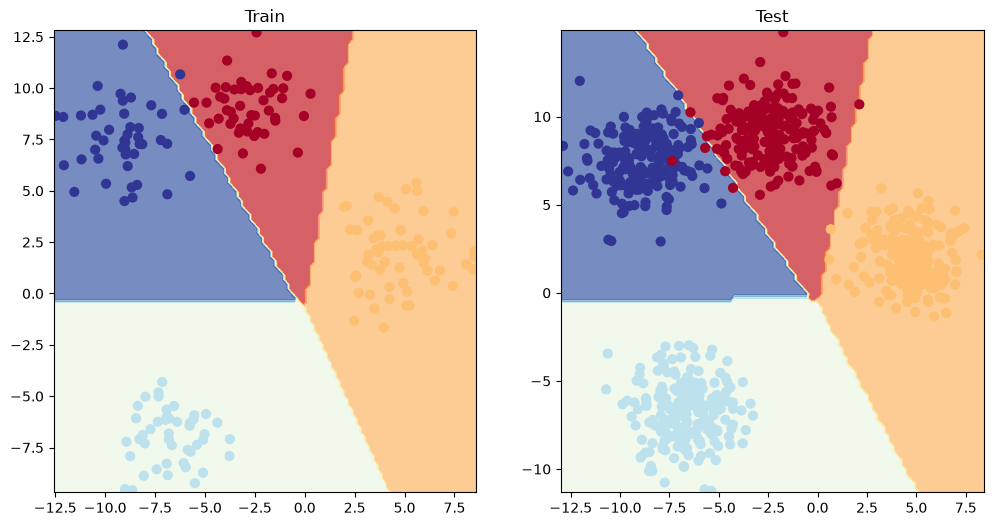

In [55]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

In [56]:
from torchmetrics import Accuracy

# Setup metric and make sure it's on the target device
torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)

# Calculate accuracy
torchmetrics_accuracy(y_preds, y_blob_test)

tensor(0.9912, device='cuda:0')